In [29]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (confusion_matrix, classification_report, 
                              accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, roc_curve)

# Model Saving
import pickle
import joblib

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## DATASET OVERVIEW

In [30]:
# Load the dataset
df = pd.read_csv('/kaggle/input/apenna/ecg_sleep_apnea_dataset.csv')

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1] - 1}")
print(f"Number of Samples: {df.shape[0]}")

print("\n" + "="*80)
print("FIRST FEW ROWS")
print("="*80)
print(df.head())

print("\n" + "="*80)
print("DATASET INFORMATION")
print("="*80)
print(df.info())

print("\n" + "="*80)
print("TARGET VARIABLE DISTRIBUTION")
print("="*80)
print(df['Target'].value_counts())
print("\nTarget Percentage:")
print(df['Target'].value_counts(normalize=True) * 100)

print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)
print(df.describe())


DATASET OVERVIEW

Dataset Shape: (2660, 2501)
Number of Features: 2500
Number of Samples: 2660

FIRST FEW ROWS
          0         1         2         3         4         5         6  \
0  0.012976  0.022008  0.049401  0.007309  0.080700  0.084465  0.053040   
1  0.007665  0.011024  0.014001  0.115614  0.045236  0.053854  0.144119   
2  0.044957  0.028612  0.085881  0.018910  0.078694  0.103297  0.046348   
3 -0.011676  0.027831  0.029627  0.021658  0.068194  0.075705  0.095863   
4 -0.008188  0.001010 -0.009165  0.061274  0.087704  0.055419  0.120823   

          7         8         9  ...      2491      2492      2493      2494  \
0  0.110527  0.147975  0.158048  ... -0.086520 -0.076036 -0.073070 -0.075017   
1  0.093378  0.178889  0.133928  ... -0.590053 -0.585818 -0.504592 -0.412495   
2  0.148435  0.148251  0.140560  ... -0.663029 -0.596072 -0.501529 -0.432133   
3  0.123471  0.155526  0.150709  ... -0.085069 -0.117560 -0.108299 -0.083278   
4  0.107706  0.133526  0.166235  ... -

## DATA CLEANING

In [31]:
print("\n" + "="*80)
print("DATA CLEANING")
print("="*80)

# Check for missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
print(f"Total Missing Values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("\nColumns with Missing Values:")
    print(missing_values[missing_values > 0])
    
    # Handle missing values (if any)
    # Option 1: Drop rows with missing values
    # df = df.dropna()
    
    # Option 2: Fill with mean/median
    # df.fillna(df.mean(), inplace=True)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicate rows...")
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

# Check data types
print("\nData Types:")
print(df.dtypes.value_counts())

print("\nData Cleaning Completed!")
print(f"Final Dataset Shape: {df.shape}")



DATA CLEANING

Missing Values:
Total Missing Values: 0

Duplicate Rows: 56
Removing duplicate rows...
Dataset shape after removing duplicates: (2604, 2501)

Data Types:
float64    2500
object        1
Name: count, dtype: int64

Data Cleaning Completed!
Final Dataset Shape: (2604, 2501)


## LABEL ENCODING

In [32]:
print("\n" + "="*80)
print("LABEL ENCODING")
print("="*80)

# Separate features and target
X = df.drop('Target', axis=1)
y = df['Target']

print(f"\nOriginal Target Classes: {y.unique()}")

# Apply Label Encoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Encoded Target Classes: {np.unique(y_encoded)}")
print(f"\nClass Mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} -> {i}")

# Save Label Encoder
joblib.dump(label_encoder, 'label_encoder.pkl')
print("\n✓ Label Encoder saved as 'label_encoder.pkl'")



LABEL ENCODING

Original Target Classes: ['Sleep Apnea' 'Normal']
Encoded Target Classes: [0 1]

Class Mapping:
  Normal -> 0
  Sleep Apnea -> 1

✓ Label Encoder saved as 'label_encoder.pkl'


## SelectKBest Method

In [33]:
print("\n" + "="*80)
print("FEATURE SELECTION - SelectKBest (Top 10 Features)")
print("="*80)

# Apply SelectKBest to select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X, y_encoded)

# Get selected feature names
selected_features_mask = selector.get_support()
selected_features = X.columns[selected_features_mask].tolist()

print(f"\nTotal Original Features: {X.shape[1]}")
print(f"Selected Features: {len(selected_features)}")

print("\nTop 10 Selected Features:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i}. {feature}")

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("\nTop 10 Feature Scores:")
print(feature_scores.head(10))

# Create new dataframe with selected features
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
X_selected_df['Target'] = y.values

# Save the dataset with selected features
X_selected_df.to_csv('dataset_with_top10_features.csv', index=False)
print("\n✓ Dataset with top 10 features saved as 'dataset_with_top10_features.csv'")

# Update X to use only selected features
X = X_selected_df.drop('Target', axis=1)



FEATURE SELECTION - SelectKBest (Top 10 Features)

Total Original Features: 2500
Selected Features: 10

Top 10 Selected Features:
  1. 533
  2. 538
  3. 557
  4. 558
  5. 772
  6. 980
  7. 2091
  8. 2244
  9. 2250
  10. 2414

Top 10 Feature Scores:
     Feature         Score
2250    2250  21998.674691
557      557  21885.015942
2414    2414  21821.264093
538      538  21795.859286
980      980  21794.077542
2091    2091  21727.829466
772      772  21720.298569
558      558  21696.578583
2244    2244  21660.993303
533      533  21651.766107

✓ Dataset with top 10 features saved as 'dataset_with_top10_features.csv'


## DATA PREPROCESSING

In [34]:
print("\n" + "="*80)
print("DATA PREPROCESSING - TRAIN-TEST SPLIT")
print("="*80)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")
print(f"Number of Features: {X_train.shape[1]}")

print("\nTarget Distribution in Training Set:")
print(pd.Series(y_train).value_counts())

print("\nTarget Distribution in Testing Set:")
print(pd.Series(y_test).value_counts())

print("\n" + "="*80)
print("FEATURE SCALING - StandardScaler")
print("="*80)

# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ StandardScaler fitted on training data")
print("✓ Training and testing data scaled")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("✓ Scaler saved as 'scaler.pkl'")

print("\nScaled Data Statistics (Training Set):")
print(f"  Mean: {X_train_scaled.mean():.6f}")
print(f"  Std: {X_train_scaled.std():.6f}")



DATA PREPROCESSING - TRAIN-TEST SPLIT

Training Set Size: 2083 samples
Testing Set Size: 521 samples
Number of Features: 10

Target Distribution in Training Set:
1    1045
0    1038
Name: count, dtype: int64

Target Distribution in Testing Set:
1    261
0    260
Name: count, dtype: int64

FEATURE SCALING - StandardScaler

✓ StandardScaler fitted on training data
✓ Training and testing data scaled
✓ Scaler saved as 'scaler.pkl'

Scaled Data Statistics (Training Set):
  Mean: 0.000000
  Std: 1.000000


## EXPLORATORY DATA ANALYSIS (EDA)


EXPLORATORY DATA ANALYSIS (EDA)


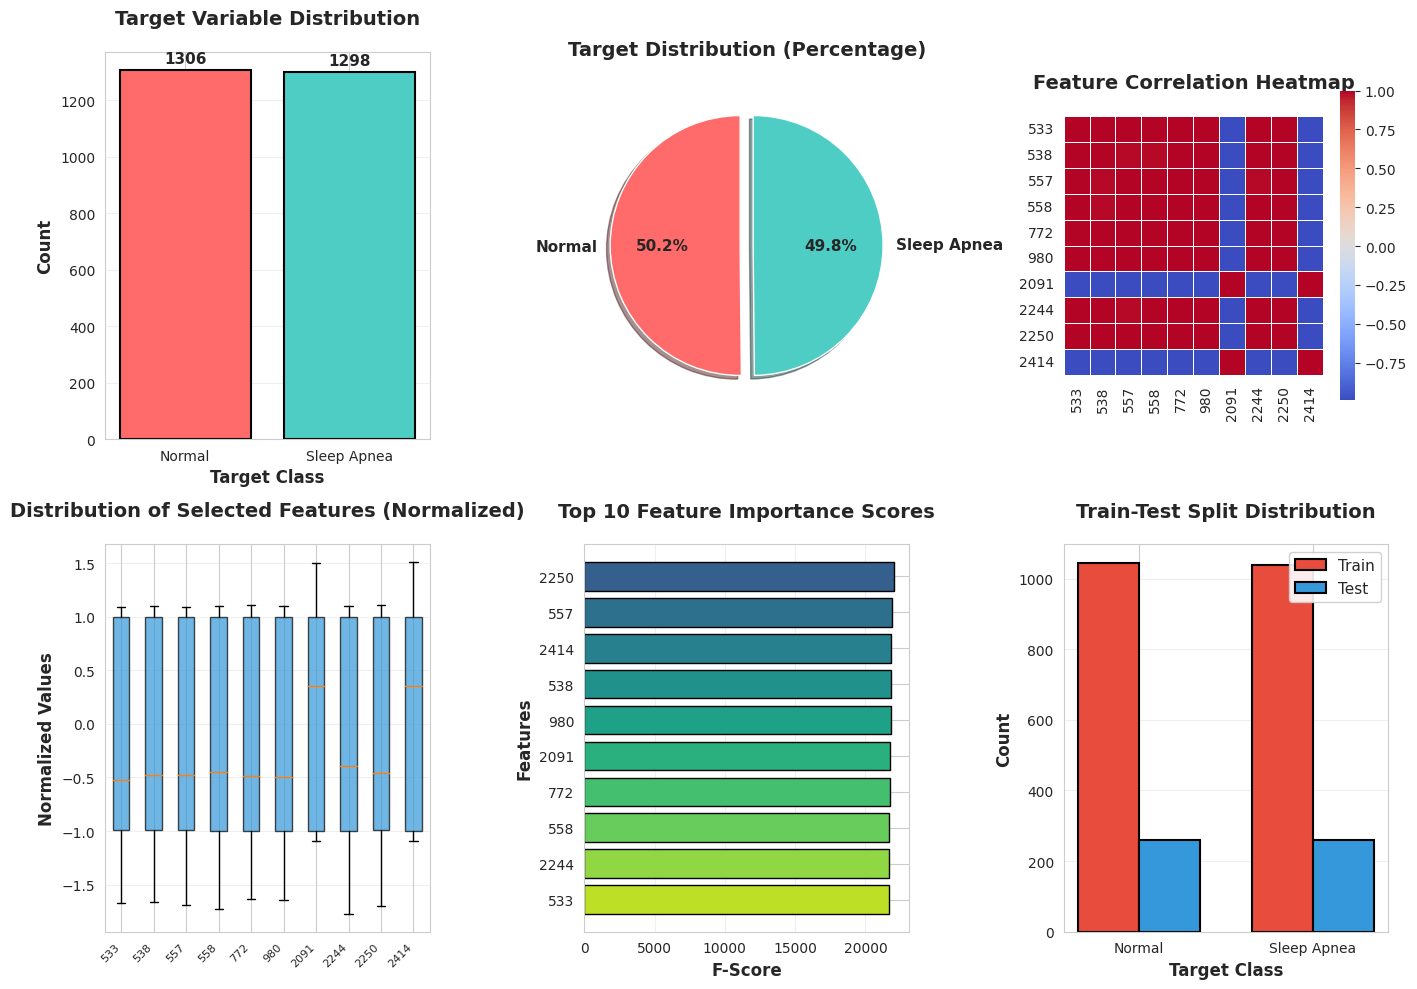


✓ EDA visualizations created and saved as 'eda_analysis.png'


In [35]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 1. Target Distribution
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
target_counts = pd.Series(y_encoded).value_counts()
colors = ['#FF6B6B', '#4ECDC4']
plt.bar(label_encoder.classes_, target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.xlabel('Target Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Target Variable Distribution', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(target_counts.values):
    plt.text(i, v + max(target_counts.values)*0.02, str(v), 
             ha='center', fontweight='bold', fontsize=11)

# 2. Target Distribution Pie Chart
plt.subplot(2, 3, 2)
plt.pie(target_counts.values, labels=label_encoder.classes_, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0.05, 0.05),
        shadow=True, textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Target Distribution (Percentage)', fontsize=14, fontweight='bold', pad=20)

# 3. Correlation Heatmap of Selected Features
plt.subplot(2, 3, 3)
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot=False)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)

# 4. Box Plot of Selected Features
plt.subplot(2, 3, 4)
X_normalized = (X - X.mean()) / X.std()
bp = plt.boxplot([X_normalized[col].values for col in X.columns], 
                  patch_artist=True, labels=X.columns)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.7)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Normalized Values', fontsize=12, fontweight='bold')
plt.title('Distribution of Selected Features (Normalized)', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# 5. Feature Importance Scores
plt.subplot(2, 3, 5)
top_features = feature_scores.head(10)
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, 10))
plt.barh(top_features['Feature'], top_features['Score'], color=colors_gradient, edgecolor='black', linewidth=1)
plt.xlabel('F-Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 10 Feature Importance Scores', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# 6. Class Balance Visualization
plt.subplot(2, 3, 6)
train_dist = pd.Series(y_train).value_counts()
test_dist = pd.Series(y_test).value_counts()

x = np.arange(len(label_encoder.classes_))
width = 0.35

bars1 = plt.bar(x - width/2, train_dist.values, width, label='Train', 
                color='#e74c3c', edgecolor='black', linewidth=1.5)
bars2 = plt.bar(x + width/2, test_dist.values, width, label='Test', 
                color='#3498db', edgecolor='black', linewidth=1.5)

plt.xlabel('Target Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Train-Test Split Distribution', fontsize=14, fontweight='bold', pad=20)
plt.xticks(x, label_encoder.classes_)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ EDA visualizations created and saved as 'eda_analysis.png'")


## MODEL TRAINING

In [36]:
print("\n" + "="*80)
print("MODEL TRAINING")
print("="*80)

# Initialize models
models = {
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
}

# Dictionary to store trained models
trained_models = {}

# Train each model
for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print(f"{'='*60}")
    
    model.fit(X_train_scaled, y_train)
    trained_models[model_name] = model
    
    print(f"✓ {model_name} training completed!")

print("\n" + "="*80)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*80)



MODEL TRAINING

Training SVM...
✓ SVM training completed!

Training Random Forest...
✓ Random Forest training completed!

Training XGBoost...
✓ XGBoost training completed!

ALL MODELS TRAINED SUCCESSFULLY!


## MODEL EVALUATION


MODEL EVALUATION

SVM - EVALUATION RESULTS

Accuracy:  0.9674 (96.74%)
Precision: 0.9674
Recall:    0.9674
F1-Score:  0.9674

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97       260
 Sleep Apnea       0.97      0.96      0.97       261

    accuracy                           0.97       521
   macro avg       0.97      0.97      0.97       521
weighted avg       0.97      0.97      0.97       521


Confusion Matrix:
[[253   7]
 [ 10 251]]


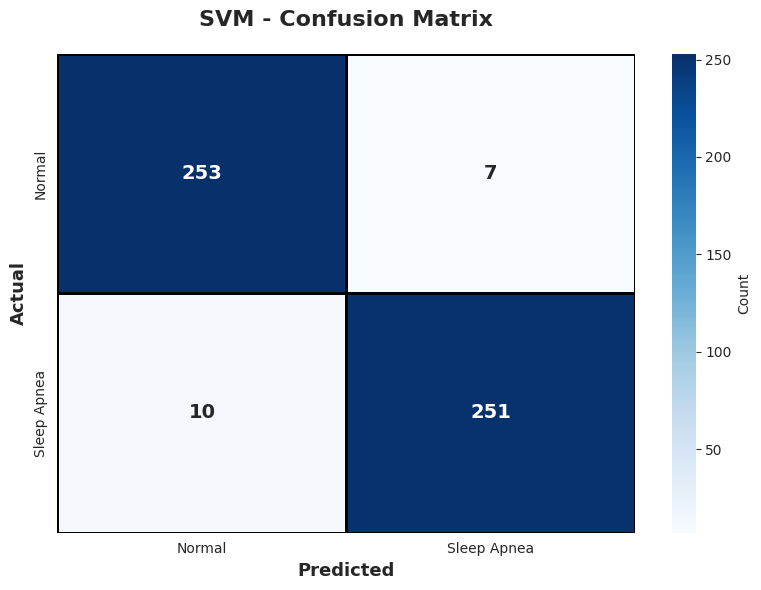


✓ Confusion Matrix saved as 'SVM_confusion_matrix.png'

Random Forest - EVALUATION RESULTS

Accuracy:  0.9597 (95.97%)
Precision: 0.9599
Recall:    0.9597
F1-Score:  0.9597

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       260
 Sleep Apnea       0.97      0.95      0.96       261

    accuracy                           0.96       521
   macro avg       0.96      0.96      0.96       521
weighted avg       0.96      0.96      0.96       521


Confusion Matrix:
[[252   8]
 [ 13 248]]


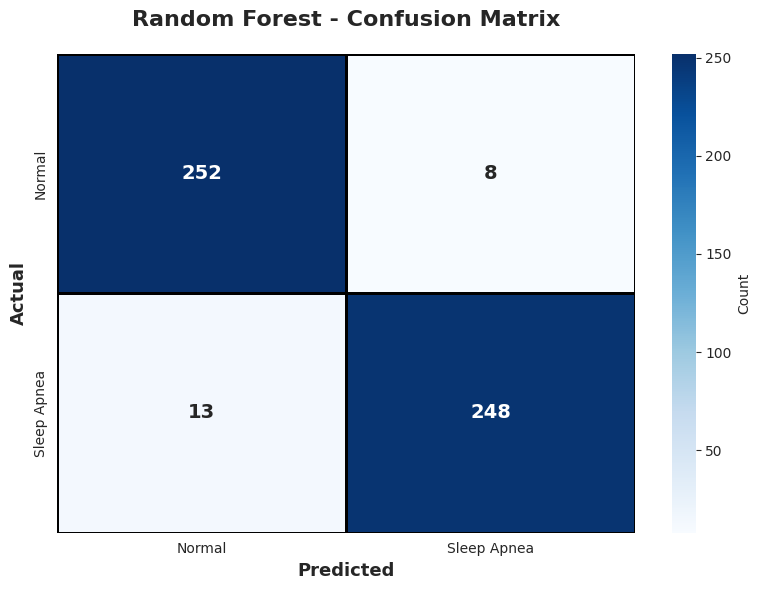


✓ Confusion Matrix saved as 'Random_Forest_confusion_matrix.png'

XGBoost - EVALUATION RESULTS

Accuracy:  0.9578 (95.78%)
Precision: 0.9579
Recall:    0.9578
F1-Score:  0.9578

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       260
 Sleep Apnea       0.96      0.95      0.96       261

    accuracy                           0.96       521
   macro avg       0.96      0.96      0.96       521
weighted avg       0.96      0.96      0.96       521


Confusion Matrix:
[[251   9]
 [ 13 248]]


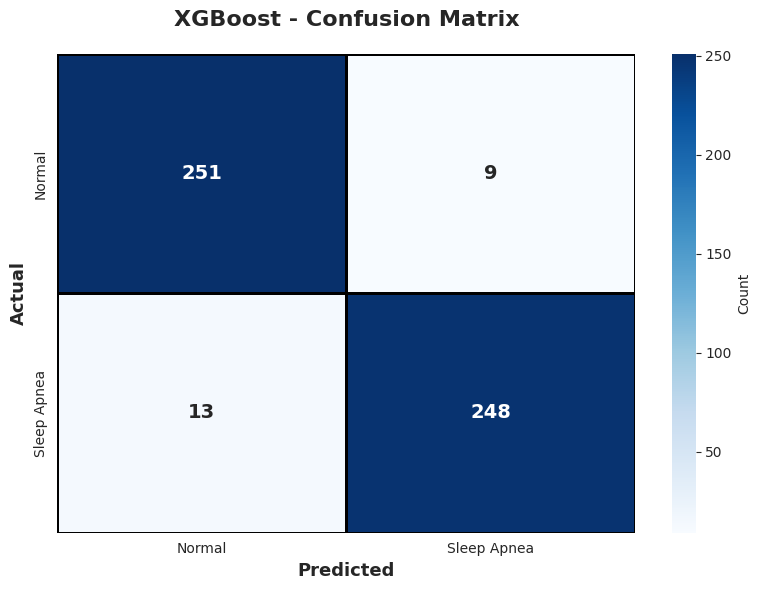


✓ Confusion Matrix saved as 'XGBoost_confusion_matrix.png'


In [37]:
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Dictionary to store results
results = {}

for model_name, model in trained_models.items():
    print(f"\n{'='*70}")
    print(f"{model_name} - EVALUATION RESULTS")
    print(f"{'='*70}")
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store results
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Predictions': y_pred,
        'Probabilities': y_pred_proba
    }
    
    print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Count'},
                linewidths=2, linecolor='black',
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Actual', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Confusion Matrix saved as '{model_name.replace(' ', '_')}_confusion_matrix.png'")


## MODEL COMPARISON


MODEL COMPARISON

        Model  Accuracy  Precision   Recall  F1-Score
          SVM  0.967370   0.967433 0.967370  0.967370
Random Forest  0.959693   0.959864 0.959693  0.959690
      XGBoost  0.957774   0.957883 0.957774  0.957772

🏆 BEST MODEL: SVM with Accuracy: 0.9674 (96.74%)


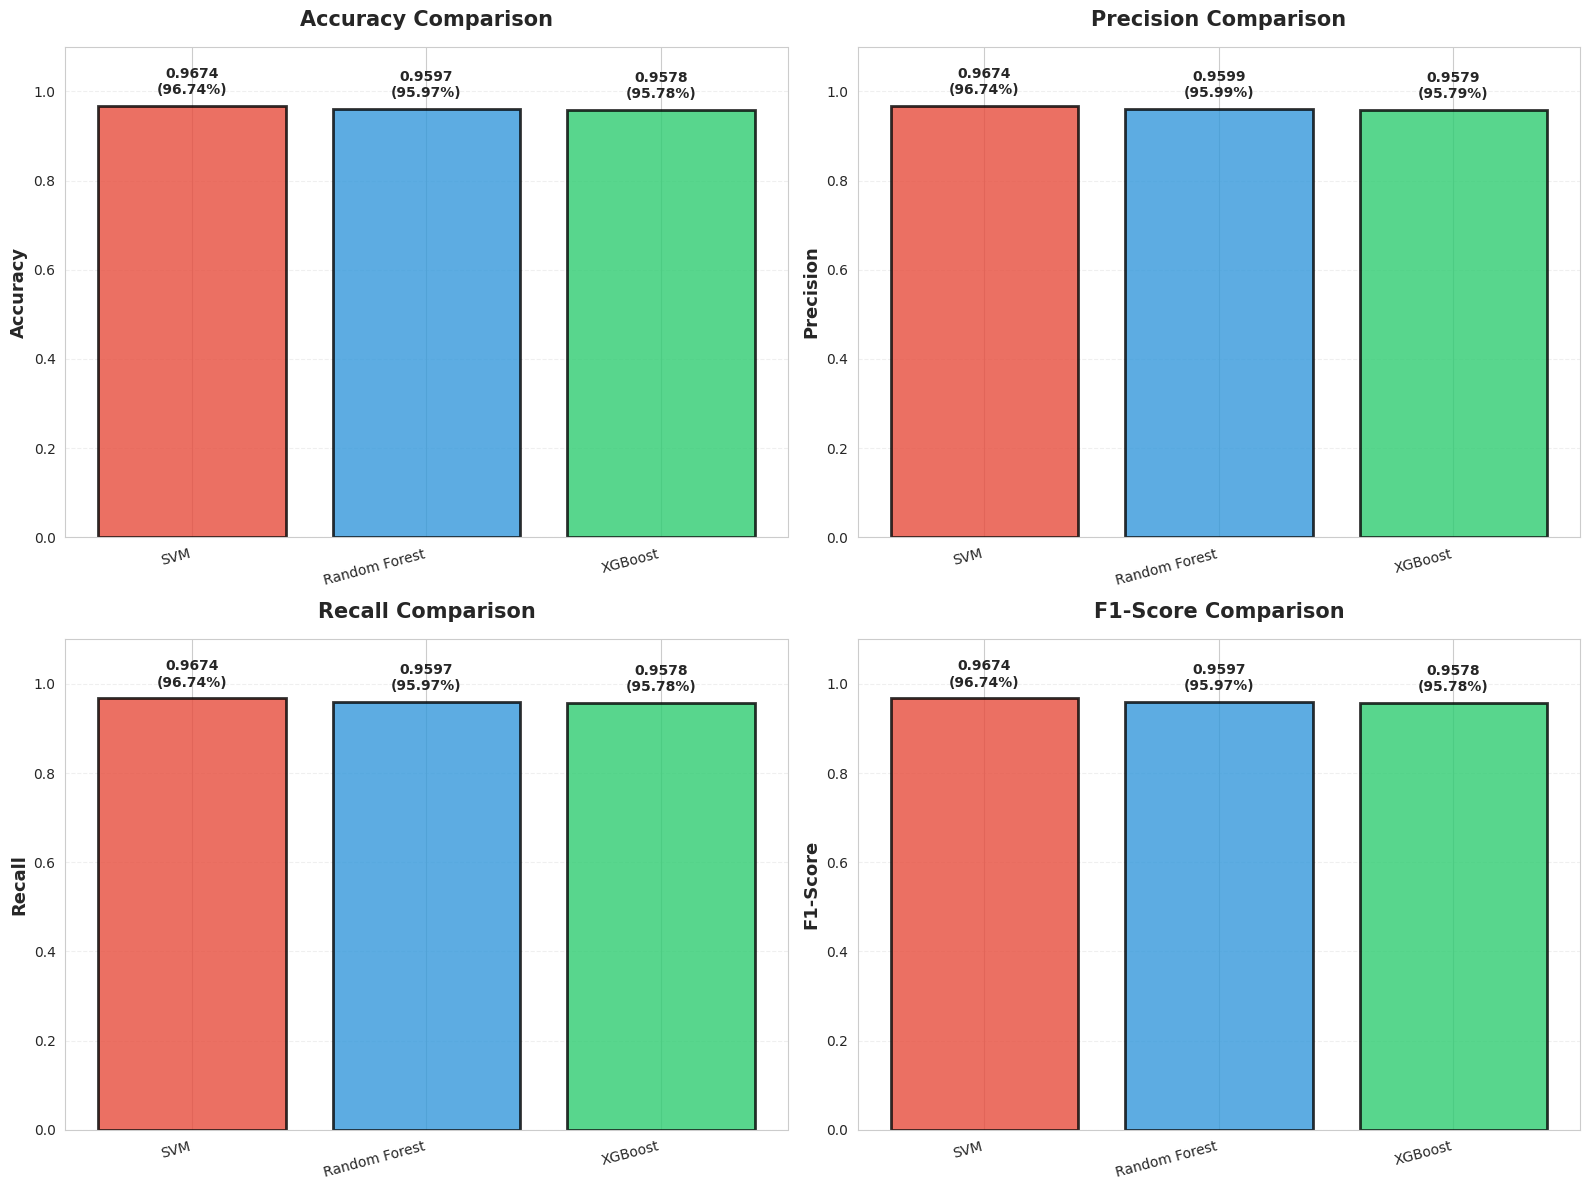


✓ Model comparison chart saved as 'model_comparison.png'
✓ Comparison results saved as 'model_comparison_results.csv'


In [38]:
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'F1-Score': [results[m]['F1-Score'] for m in results.keys()]
})

print("\n" + comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_accuracy = comparison_df['Accuracy'].max()

print(f"\n{'='*70}")
print(f"🏆 BEST MODEL: {best_model_name} with Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Visualization - Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_list = ['#e74c3c', '#3498db', '#2ecc71']

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], 
                   color=colors_list, edgecolor='black', linewidth=2, alpha=0.8)
    
    ax.set_ylabel(metric, fontsize=13, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}\n({height*100:.2f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Rotate x-axis labels
    ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison chart saved as 'model_comparison.png'")

# Save comparison results to CSV
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("✓ Comparison results saved as 'model_comparison_results.csv'")


## SAVING TRAINED MODELS

In [39]:
print("\n" + "="*80)
print("SAVING TRAINED MODELS")
print("="*80)

# Save each trained model
for model_name, model in trained_models.items():
    filename = f'{model_name.replace(" ", "_")}_model.pkl'
    joblib.dump(model, filename)
    print(f"✓ {model_name} saved as '{filename}'")

print("\n✓ All models saved successfully!")



SAVING TRAINED MODELS
✓ SVM saved as 'SVM_model.pkl'
✓ Random Forest saved as 'Random_Forest_model.pkl'
✓ XGBoost saved as 'XGBoost_model.pkl'

✓ All models saved successfully!


## QUICK PREDICTION TEMPLATE

In [40]:
# ============================================================================
# QUICK PREDICTION TEMPLATE
# ============================================================================

import numpy as np
import joblib

# Load models
scaler = joblib.load('/kaggle/working/scaler.pkl')
label_encoder = joblib.load('/kaggle/working/label_encoder.pkl')
model = joblib.load('/kaggle/working/Random_Forest_model.pkl')  # Change to any model you want

# YOUR INPUT VALUES HERE (10 features)
my_input = [
    0.012976,   # Feature 0
    0.022008,   # Feature 1
    0.049401,   # Feature 2
    0.007309,   # Feature 3
    0.080700,   # Feature 4
    0.084465,   # Feature 5
    0.053040,   # Feature 6
    0.110527,   # Feature 7
    0.147975,   # Feature 8
    0.158048    # Feature 9
]

# Make prediction
input_scaled = scaler.transform(np.array(my_input).reshape(1, -1))
prediction = model.predict(input_scaled)
predicted_class = label_encoder.inverse_transform(prediction)[0]
probabilities = model.predict_proba(input_scaled)[0]

# Display result
print(f"\n🎯 PREDICTION: {predicted_class}")
print(f"\n📊 Probabilities:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"   {class_name}: {probabilities[i]:.4f} ({probabilities[i]*100:.2f}%)")



🎯 PREDICTION: Normal

📊 Probabilities:
   Normal: 0.6099 (60.99%)
   Sleep Apnea: 0.3901 (39.01%)
